In [26]:
import numpy as np
import matplotlib.pyplot as plt


class RungeKutta:
    def __init__(self, A, b, c, ko=1):
        self.A = A
        self.b = b
        self.c = c
        self.ko = ko
        self.s = len(b)
        self.explicit = True

        self.explicit = np.allclose(A, np.tril(A, k=-1))


    def step(self, t, u, tau, f):
        k = np.zeros((self.s, len(u)))

        for i in range(self.s):
            u_stage = u + tau * self.A[i, :i] @ k[:i]

            k[i] = f(t + self.c[i] * tau, u_stage)
        return u + tau * self.b @ k



# Two examples of RK methods, you can add more and use them in the exercises
ExplicitEuler = RungeKutta(
    A=np.array([[0]]),
    b=np.array([1]),
    c=np.array([0]),
    ko=1
)

ImprovedEuler = RungeKutta(
    A=np.array([[0, 0],
                [1, 0]]),
    b=np.array([0.5, 0.5]),
    c=np.array([0, 1]),
    ko=2
)

RK4 = RungeKutta(
    A=np.array([[0,   0,   0,   0],
                [0.5, 0,   0,   0],
                [0,   0.5, 0,   0],
                [0,   0,   1,   0]]),
    b=np.array([1/6, 1/3, 1/3, 1/6]),
    c=np.array([0, 0.5, 0.5, 1]),
    ko=4
)

In [27]:
def f(t, u):
    u0, u1 = u
    return np.array([
        -4 * u1**5 + 2 * u0 * u1,
        5 * u0**3 - u1**2
    ])

done


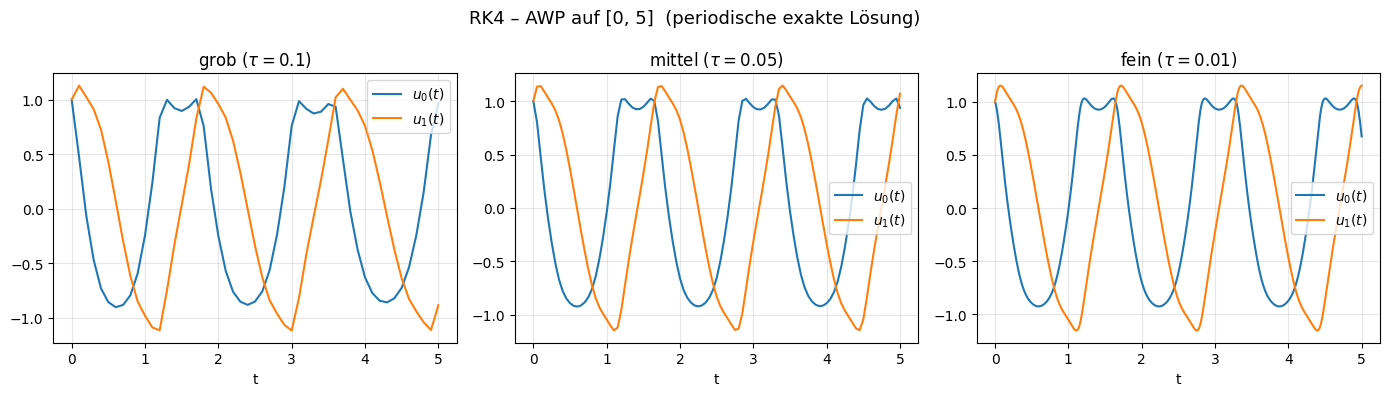

In [28]:
def solve(rk, f, u0, t0, T, tau):
    ts = [t0]
    us = [u0.copy()]
    t = t0
    u = u0.copy()
    while t < T - 1e-12:
        tau_actual = min(tau, T - t)
        u = rk.step(t, u, tau_actual, f)
        t += tau_actual
        ts.append(t)
        us.append(u.copy())
    return np.array(ts), np.array(us)
 
u0 = np.array([1.0, 1.0])
T = 5.0
 
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
taus = [0.1, 0.05, 0.01]
labels = ['grob ($\\tau=0.1$)', 'mittel ($\\tau=0.05$)', 'fein ($\\tau=0.01$)']
 
for ax, tau, lbl in zip(axes, taus, labels):
    ts, us = solve(RK4, f, u0, 0, T, tau)
    if np.any(np.abs(us) > 1e6):
        ax.text(0.5, 0.5, 'divergiert', transform=ax.transAxes,
                ha='center', va='center', fontsize=13, color='red')
    else:
        ax.plot(ts, us[:, 0], label='$u_0(t)$')
        ax.plot(ts, us[:, 1], label='$u_1(t)$')
        ax.legend()
    ax.set_title(lbl)
    ax.set_xlabel('t')
    ax.grid(True, alpha=0.3)
 
fig.suptitle('RK4 – AWP auf [0, 5]  (periodische exakte Lösung)', fontsize=13)
plt.tight_layout()
print("done")